In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load featured dataset
df = pd.read_csv("../data/processed/online_retail_featured.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Load RFM
rfm = pd.read_csv("../data/features/rfm_features.csv")

# Load daily sales
daily_sales = pd.read_csv("../data/features/daily_sales.csv")
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

print("All datasets loaded!")
print(f"Main dataset:  {df.shape}")
print(f"RFM table:     {rfm.shape}")
print(f"Daily sales:   {daily_sales.shape}")

All datasets loaded!
Main dataset:  (779425, 16)
RFM table:     (5878, 5)
Daily sales:   (604, 4)


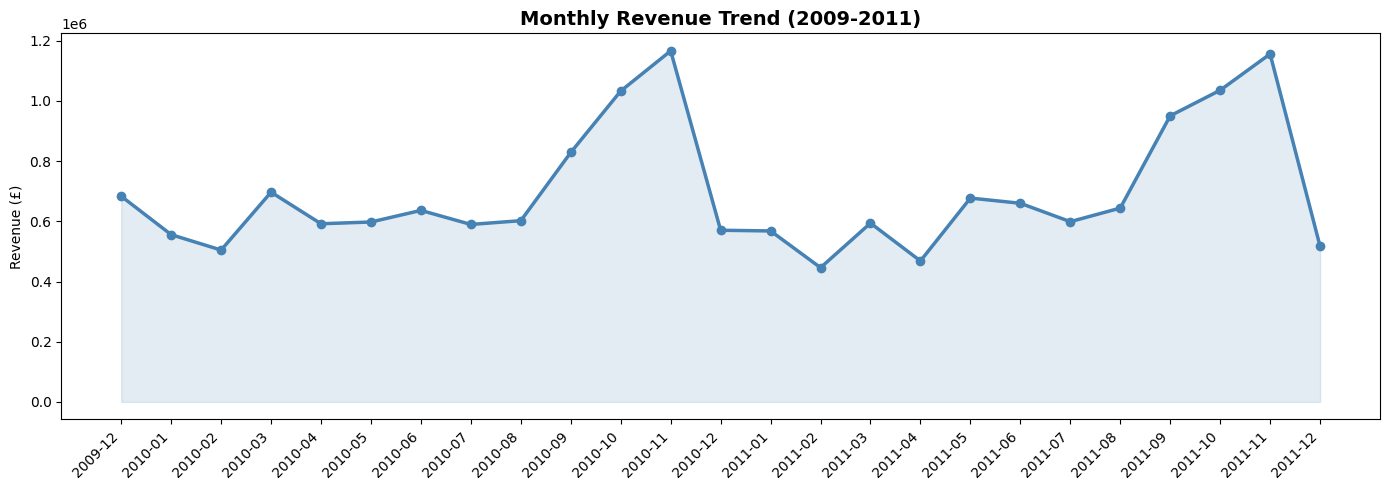

Peak month: 2010-11
Peak revenue: £ 1166460.02
Lowest month: 2011-02


In [2]:
# Monthly revenue trend
monthly = df.groupby(['Year', 'Month'])['TotalRevenue'].sum().reset_index()
monthly['YearMonth'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['TotalRevenue'], 
         marker='o', color='steelblue', linewidth=2.5, markersize=6)
plt.fill_between(range(len(monthly)), monthly['TotalRevenue'], 
                 alpha=0.15, color='steelblue')
plt.xticks(range(len(monthly)), monthly['YearMonth'], rotation=45, ha='right')
plt.title('Monthly Revenue Trend (2009-2011)', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/plots/eda_monthly_revenue.png', dpi=150)
plt.show()

print("Peak month:", monthly.loc[monthly['TotalRevenue'].idxmax(), 'YearMonth'])
print("Peak revenue: £", round(monthly['TotalRevenue'].max(), 2))
print("Lowest month:", monthly.loc[monthly['TotalRevenue'].idxmin(), 'YearMonth'])

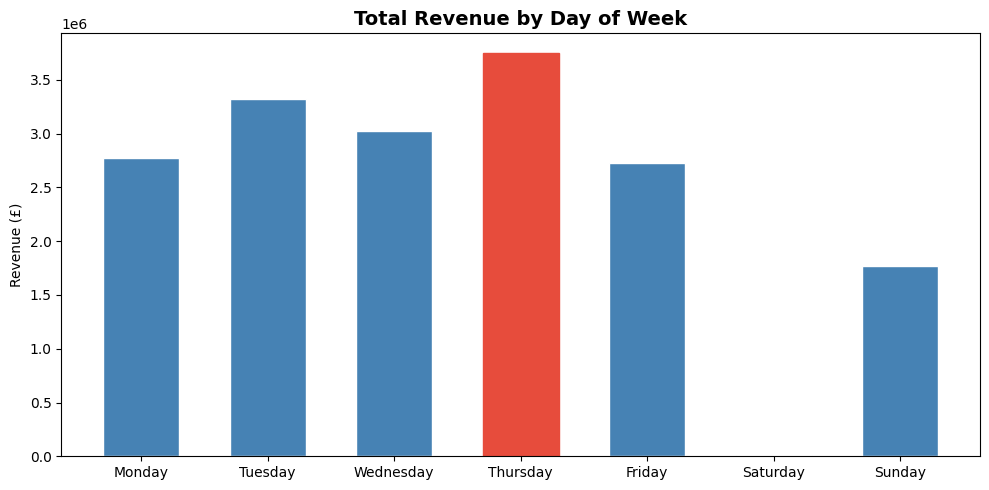

Revenue by day:
  Monday       £2,778,201.57
  Tuesday      £3,322,830.14
  Wednesday    £3,021,043.85
  Thursday     £3,745,783.43
  Friday       £2,728,473.17
  Saturday     £    9,803.05
  Sunday       £1,768,669.05


In [3]:
# Revenue by day of week
day_names = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 
             3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}

dow = df.groupby('DayOfWeek')['TotalRevenue'].sum().reset_index()
dow['DayName'] = dow['DayOfWeek'].map(day_names)

plt.figure(figsize=(10, 5))
bars = plt.bar(dow['DayName'], dow['TotalRevenue'], 
               color='steelblue', edgecolor='white', width=0.6)

# Highlight highest bar
max_idx = dow['TotalRevenue'].idxmax()
bars[max_idx].set_color('#e74c3c')

plt.title('Total Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/plots/eda_day_of_week.png', dpi=150)
plt.show()

print("Revenue by day:")
for _, row in dow.iterrows():
    print(f"  {row['DayName']:<12} £{row['TotalRevenue']:>12,.2f}")

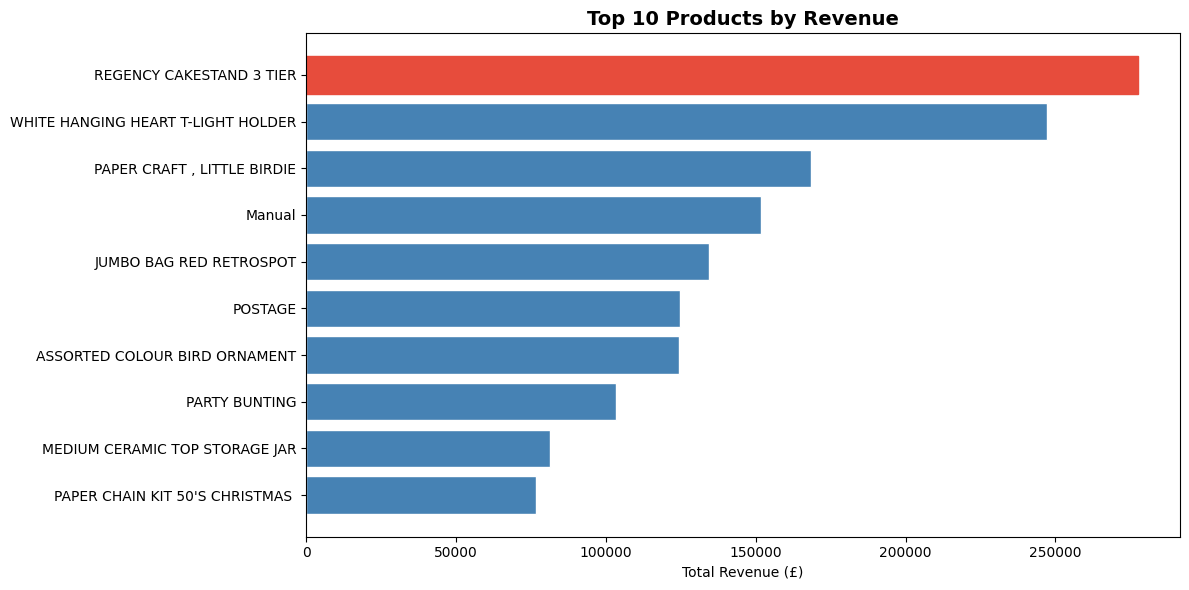

Top 5 products:
  REGENCY CAKESTAND 3 TIER                      £277,656.25
  WHITE HANGING HEART T-LIGHT HOLDER            £247,048.01
  PAPER CRAFT , LITTLE BIRDIE                   £168,469.60
  Manual                                        £151,777.67
  JUMBO BAG RED RETROSPOT                       £134,307.44


In [4]:
# Top 10 products by revenue
top_products = df.groupby('Description')['TotalRevenue'].sum()\
                 .sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_products.index, top_products.values, 
                color='steelblue', edgecolor='white')
bars[-1].set_color('#e74c3c')  # highlight top product

plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/plots/eda_top_products.png', dpi=150)
plt.show()

print("Top 5 products:")
top5 = df.groupby('Description')['TotalRevenue'].sum()\
         .sort_values(ascending=False).head()
for prod, rev in top5.items():
    print(f"  {prod:<45} £{rev:>10,.2f}")

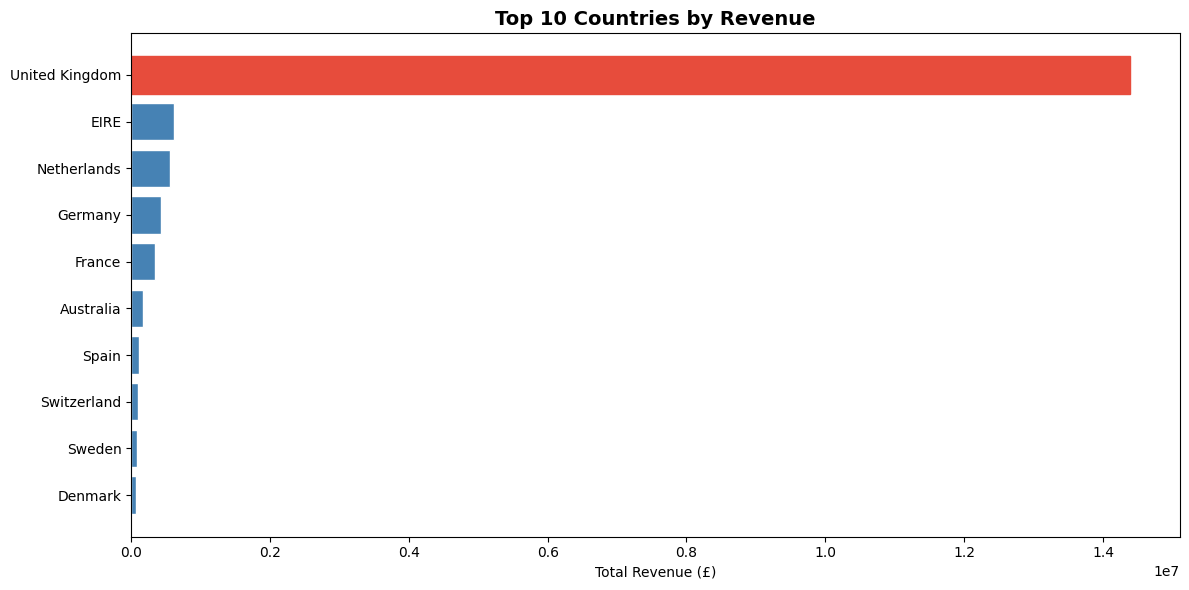

UK Revenue:            £14,389,234.92
Rest of World Revenue: £2,985,569.35
UK share of total:     82.8%


In [5]:
# Top 10 countries by revenue
top_countries = df.groupby('Country')['TotalRevenue'].sum()\
                  .sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_countries.index, top_countries.values,
                color='steelblue', edgecolor='white')
bars[-1].set_color('#e74c3c')  # highlight top country

plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/plots/eda_top_countries.png', dpi=150)
plt.show()

# UK vs rest of world
uk_rev = df[df['Country']=='United Kingdom']['TotalRevenue'].sum()
total_rev = df['TotalRevenue'].sum()
print(f"UK Revenue:            £{uk_rev:,.2f}")
print(f"Rest of World Revenue: £{total_rev - uk_rev:,.2f}")
print(f"UK share of total:     {uk_rev/total_rev*100:.1f}%")

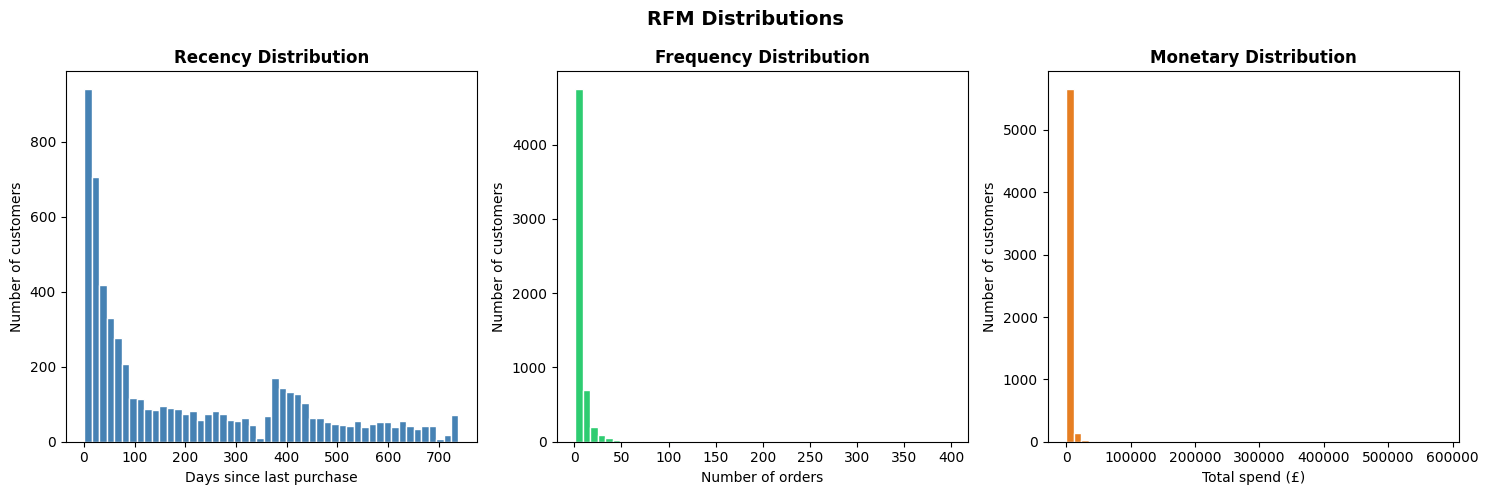

RFM Statistics:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


In [6]:
#RMF DISTRIBUTION
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency
axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')

# Frequency
axes[1].hist(rfm['Frequency'], bins=50, color='#2ecc71', edgecolor='white')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Number of customers')

# Monetary
axes[2].hist(rfm['Monetary'], bins=50, color='#e67e22', edgecolor='white')
axes[2].set_title('Monetary Distribution', fontweight='bold')
axes[2].set_xlabel('Total spend (£)')
axes[2].set_ylabel('Number of customers')

plt.suptitle('RFM Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/plots/eda_rfm_distributions.png', dpi=150)
plt.show()

print("RFM Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

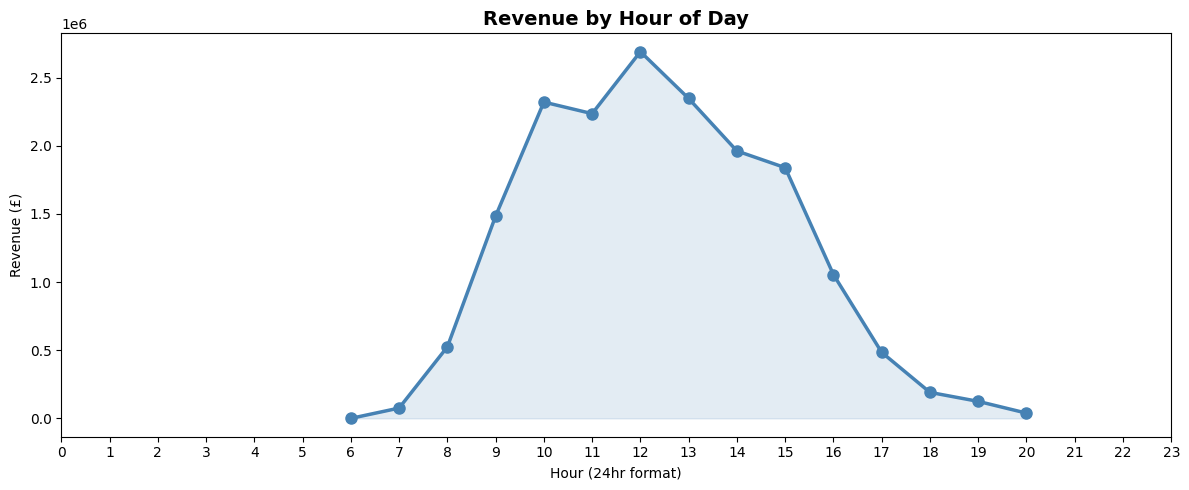

Peak hour: 12 :00
Lowest hour: 6 :00


In [7]:
# Revenue by hour of day
hourly = df.groupby('Hour')['TotalRevenue'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly['Hour'], hourly['TotalRevenue'], 
         marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(hourly['Hour'], hourly['TotalRevenue'], 
                 alpha=0.15, color='steelblue')
plt.xticks(range(0, 24))
plt.title('Revenue by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (24hr format)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/plots/eda_hourly_sales.png', dpi=150)
plt.show()

print("Peak hour:", hourly.loc[hourly['TotalRevenue'].idxmax(), 'Hour'], ":00")
print("Lowest hour:", hourly.loc[hourly['TotalRevenue'].idxmin(), 'Hour'], ":00")

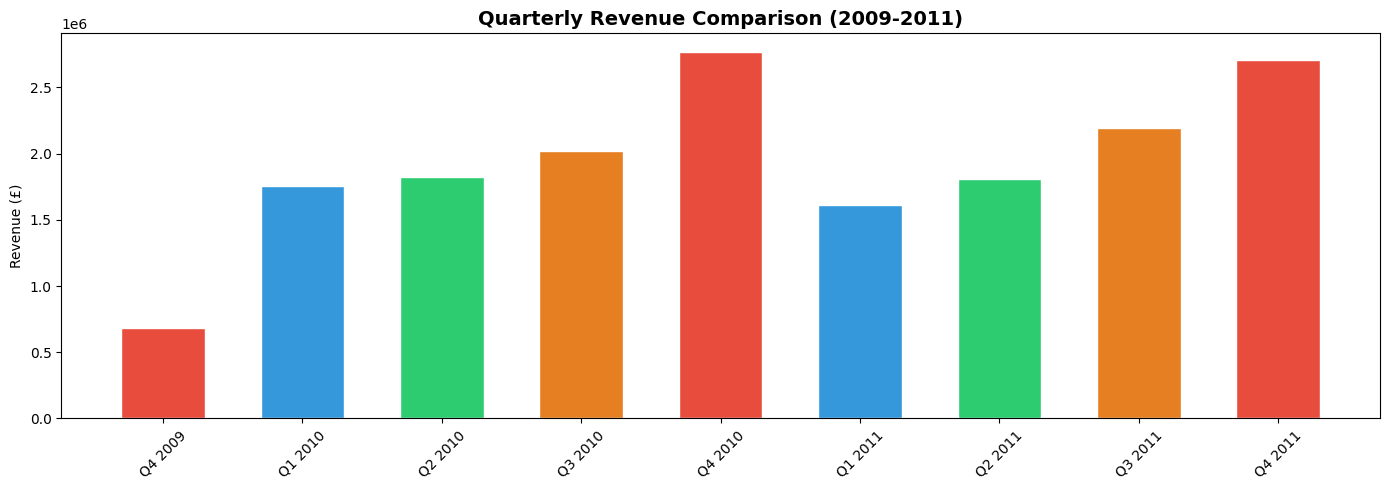

Quarterly Revenue:
  Q4 2009    £  683,504.01
  Q1 2010    £1,757,340.10
  Q2 2010    £1,826,186.51
  Q3 2010    £2,020,974.72
  Q4 2010    £2,769,994.76
  Q1 2011    £1,608,267.99
  Q2 2011    £1,805,775.53
  Q3 2011    £2,193,704.14
  Q4 2011    £2,709,056.50


In [8]:
# Quarterly revenue
quarterly = df.groupby(['Year', 'Quarter'])['TotalRevenue'].sum().reset_index()
quarterly['Label'] = 'Q' + quarterly['Quarter'].astype(str) + ' ' + quarterly['Year'].astype(str)

colors = ['#3498db','#2ecc71','#e67e22','#e74c3c']
quarter_colors = [colors[q-1] for q in quarterly['Quarter']]

plt.figure(figsize=(14, 5))
bars = plt.bar(quarterly['Label'], quarterly['TotalRevenue'],
               color=quarter_colors, edgecolor='white', width=0.6)
plt.title('Quarterly Revenue Comparison (2009-2011)', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/plots/eda_quarterly_revenue.png', dpi=150)
plt.show()

print("Quarterly Revenue:")
for _, row in quarterly.iterrows():
    print(f"  {row['Label']:<10} £{row['TotalRevenue']:>12,.2f}")